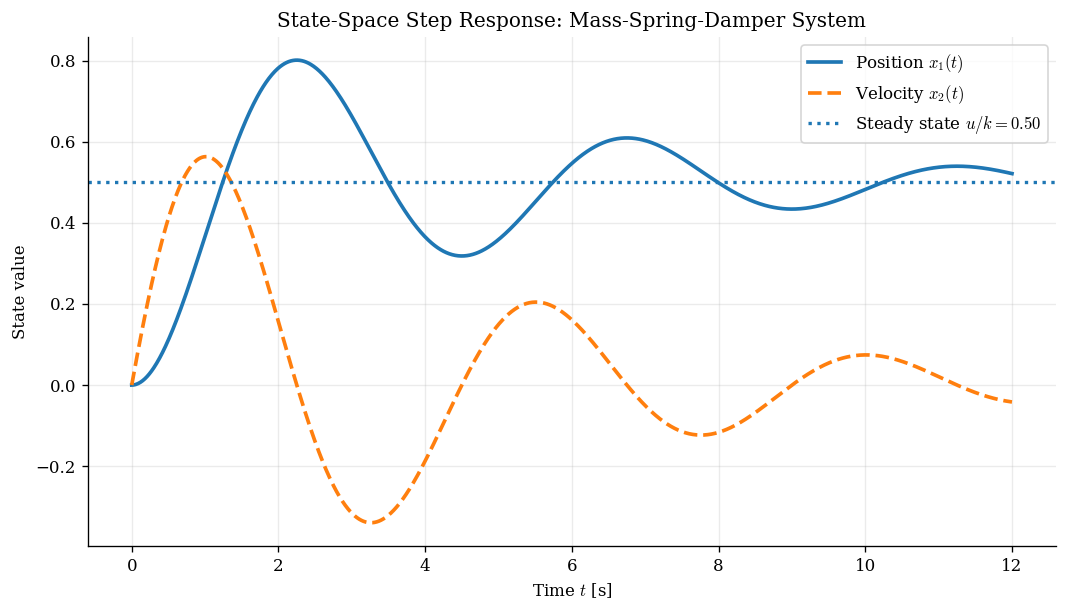

In [1]:
"""
State-Space Step Response Plot Recipe

Author: Ziraddin Gulumjanli, 2026

This script visualizes a simple second-order mass-spring-damper system using
state-space dynamics.

System:
    x_dot = A x + B u
    y     = C x + D u

State:
    x = [position, velocity]^T

The example is intentionally dependency-light: NumPy + Matplotlib only.
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


@dataclass(frozen=True)
class MassSpringDamperConfig:
    """Configuration for the mass-spring-damper system."""

    mass: float = 1.0
    damping: float = 0.45
    stiffness: float = 2.0
    step_force: float = 1.0
    duration: float = 12.0
    dt: float = 0.01
    output_dir: Path = Path("figures")


def configure_matplotlib() -> None:
    """Apply publication-style Matplotlib settings."""

    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "savefig.dpi": 600,
            "font.family": "serif",
            "mathtext.fontset": "cm",
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": True,
            "grid.alpha": 0.25,
            "lines.linewidth": 2.2,
        }
    )


def build_state_space_matrices(config: MassSpringDamperConfig) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Create A, B, C, D matrices for a mass-spring-damper system."""

    m = config.mass
    c = config.damping
    k = config.stiffness

    a_matrix = np.array([[0.0, 1.0], [-k / m, -c / m]])
    b_matrix = np.array([[0.0], [1.0 / m]])
    c_matrix = np.array([[1.0, 0.0]])
    d_matrix = np.array([[0.0]])

    return a_matrix, b_matrix, c_matrix, d_matrix


def rk4_step(
    state: np.ndarray,
    control_input: float,
    dt: float,
    a_matrix: np.ndarray,
    b_matrix: np.ndarray,
) -> np.ndarray:
    """Advance one simulation step using fourth-order Runge-Kutta integration."""

    def dynamics(current_state: np.ndarray) -> np.ndarray:
        return a_matrix @ current_state + b_matrix[:, 0] * control_input

    k1 = dynamics(state)
    k2 = dynamics(state + 0.5 * dt * k1)
    k3 = dynamics(state + 0.5 * dt * k2)
    k4 = dynamics(state + dt * k3)

    return state + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def simulate_step_response(config: MassSpringDamperConfig) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Simulate the state-space model response to a constant step input."""

    a_matrix, b_matrix, _, _ = build_state_space_matrices(config)

    time = np.arange(0.0, config.duration + config.dt, config.dt)
    states = np.zeros((time.size, 2), dtype=float)
    control = np.full(time.size, config.step_force, dtype=float)

    for step_idx in range(1, time.size):
        states[step_idx] = rk4_step(
            state=states[step_idx - 1],
            control_input=control[step_idx],
            dt=config.dt,
            a_matrix=a_matrix,
            b_matrix=b_matrix,
        )

    return time, states, control


def plot_state_space_response(
    time: np.ndarray,
    states: np.ndarray,
    config: MassSpringDamperConfig,
) -> plt.Figure:
    """Plot displacement and velocity response."""

    position = states[:, 0]
    velocity = states[:, 1]
    steady_state_position = config.step_force / config.stiffness

    fig, ax = plt.subplots(figsize=(9.0, 5.2))

    ax.plot(time, position, label=r"Position $x_1(t)$")
    ax.plot(time, velocity, linestyle="--", label=r"Velocity $x_2(t)$")
    ax.axhline(
        steady_state_position,
        linestyle=":",
        linewidth=2.0,
        label=rf"Steady state $u/k={steady_state_position:.2f}$",
    )

    ax.set_title("State-Space Step Response: Mass-Spring-Damper System")
    ax.set_xlabel(r"Time $t$ [s]")
    ax.set_ylabel("State value")
    ax.legend(frameon=True)
    fig.tight_layout()

    return fig


def main() -> None:
    """Run the recipe and save the figure."""

    configure_matplotlib()

    config = MassSpringDamperConfig()
    config.output_dir.mkdir(parents=True, exist_ok=True)

    time, states, _ = simulate_step_response(config)
    fig = plot_state_space_response(time=time, states=states, config=config)

    fig.savefig(config.output_dir / "control_state_space_response.png", bbox_inches="tight")
    fig.savefig(config.output_dir / "control_state_space_response.pdf", bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    main()
